# Part 1

- Tratamento e Exploração


In [225]:
#pip install watermark

In [226]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [227]:
%reload_ext watermark
%watermark -a "Matheus dos Anjos" --iversions

Author: Matheus dos Anjos

pandas    : 2.2.3
numpy     : 2.1.3
sklearn   : 1.6.1
matplotlib: 3.10.0
seaborn   : 0.13.2



In [228]:
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)
sns.set_palette("magma")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

In [229]:
df = pd.read_csv("C:/Users/36129382023.2n/Desktop/Projetos-/Projetos Python/ISP_Prova_Senac/BaseDPEvolucaoMensalCisp.csv", sep=";", encoding="latin1")

In [230]:
df.head(3)

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,21,2,0,0,0,0,578,3
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,15,6,0,1,0,0,441,3
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,47,2,1,0,0,0,637,3


In [231]:
df.tail(3)

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
36626,166,8,2025,2025m08,33,5,Angra dos Reis,3300100,Interior,3,...,11.0,3.0,63,8,0,0,0,0,595,2
36627,167,8,2025,2025m08,43,5,Paraty,3303807,Interior,0,...,3.0,0.0,13,2,0,1,0,0,234,2
36628,168,8,2025,2025m08,28,5,Rio Claro,3304409,Interior,1,...,1.0,0.0,5,0,0,0,0,0,50,2


In [232]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36629 entries, 0 to 36628
Data columns (total 63 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cisp                        36629 non-null  int64  
 1   mes                         36629 non-null  int64  
 2   ano                         36629 non-null  int64  
 3   mes_ano                     36629 non-null  object 
 4   aisp                        36629 non-null  int64  
 5   risp                        36629 non-null  int64  
 6   munic                       36629 non-null  object 
 7   mcirc                       36629 non-null  int64  
 8   regiao                      36629 non-null  object 
 9   hom_doloso                  36629 non-null  int64  
 10  lesao_corp_morte            36629 non-null  int64  
 11  latrocinio                  36629 non-null  int64  
 12  cvli                        36629 non-null  int64  
 13  hom_por_interv_policial     366

In [233]:
df['mes_ano'] = df['mes_ano'].str.replace('m', '/')
df['mes_ano'] = pd.to_datetime(df['mes_ano'], format='%Y/%m')

In [234]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36629 entries, 0 to 36628
Data columns (total 63 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   cisp                        36629 non-null  int64         
 1   mes                         36629 non-null  int64         
 2   ano                         36629 non-null  int64         
 3   mes_ano                     36629 non-null  datetime64[ns]
 4   aisp                        36629 non-null  int64         
 5   risp                        36629 non-null  int64         
 6   munic                       36629 non-null  object        
 7   mcirc                       36629 non-null  int64         
 8   regiao                      36629 non-null  object        
 9   hom_doloso                  36629 non-null  int64         
 10  lesao_corp_morte            36629 non-null  int64         
 11  latrocinio                  36629 non-null  int64     

In [235]:
df = df.groupby('mes_ano', as_index=False)['registro_ocorrencias'].sum()

In [236]:
df.head()

,mes_ano,registro_ocorrencias
0,2003-01-01,44793
1,2003-02-01,45403
2,2003-03-01,45417
3,2003-04-01,44184
4,2003-05-01,45572


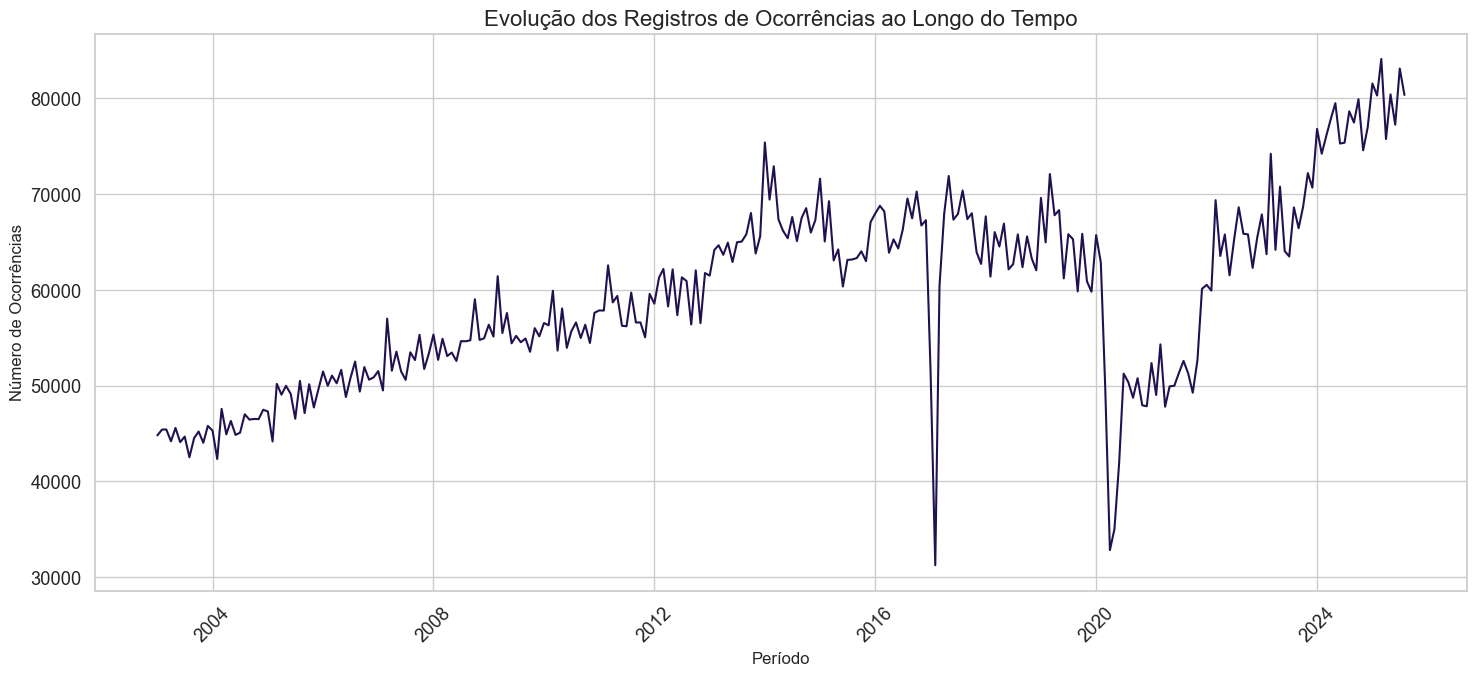

In [237]:
plt.figure(figsize=(15,7))
plt.plot(df['mes_ano'], df['registro_ocorrencias'])
plt.title('Evolução dos Registros de Ocorrências ao Longo do Tempo')
plt.xlabel('Período')
plt.ylabel('Número de Ocorrências')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [238]:
print("Estatísticas descritivas dos registros:")
print(df['registro_ocorrencias'].describe())

Estatísticas descritivas dos registros:
count      272.000000
mean     59419.963235
std       9705.375612
min      31231.000000
25%      51547.750000
50%      59914.500000
75%      65856.750000
max      84129.000000
Name: registro_ocorrencias, dtype: float64


In [239]:
'''Window=6:

Significa que está calculando a média dos últimos 6 meses
Para cada ponto no tempo, soma os 6 valores anteriores e divide por 6
Ajuda a reduzir ruídos de curto prazo
Funcionamento:

Por exemplo, para calcular a média móvel de junho/2003:
Soma os valores de janeiro a junho
Divide por 6
Para julho/2003:
Soma os valores de fevereiro a julho
Divide por 6
E assim sucessivamente
Vantagens:

Suaviza variações sazonais
Destaca tendências de longo prazo
Facilita a visualização de padrões
Limitações:

Os primeiros 5 meses não terão média móvel (serão NaN)
Pode mascarar mudanças abruptas importantes
A escolha do período (6 meses neste caso) afeta a análise'''

'Window=6:\n\nSignifica que está calculando a média dos últimos 6 meses\nPara cada ponto no tempo, soma os 6 valores anteriores e divide por 6\nAjuda a reduzir ruídos de curto prazo\nFuncionamento:\n\nPor exemplo, para calcular a média móvel de junho/2003:\nSoma os valores de janeiro a junho\nDivide por 6\nPara julho/2003:\nSoma os valores de fevereiro a julho\nDivide por 6\nE assim sucessivamente\nVantagens:\n\nSuaviza variações sazonais\nDestaca tendências de longo prazo\nFacilita a visualização de padrões\nLimitações:\n\nOs primeiros 5 meses não terão média móvel (serão NaN)\nPode mascarar mudanças abruptas importantes\nA escolha do período (6 meses neste caso) afeta a análise'

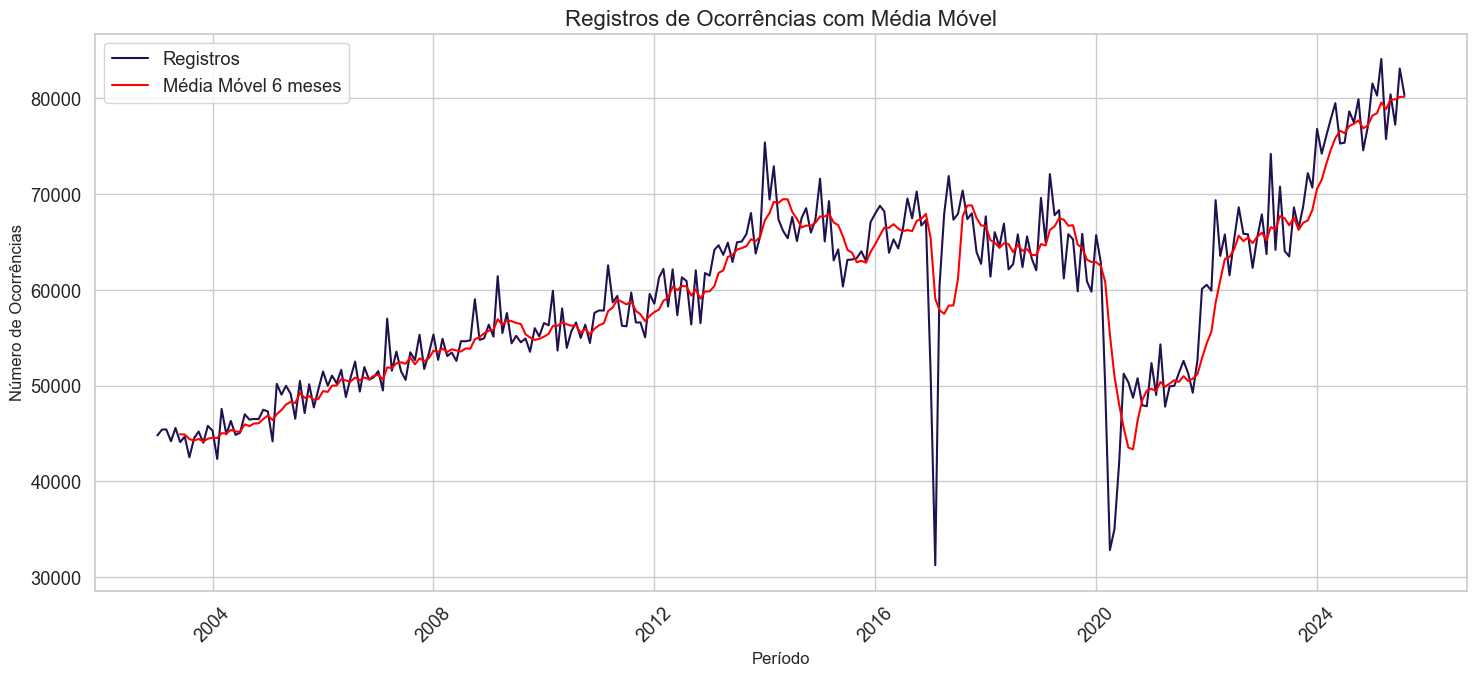

In [240]:
df['media_movel_6m'] = df['registro_ocorrencias'].rolling(window=6).mean()
plt.figure(figsize=(15,7))
plt.plot(df['mes_ano'], df['registro_ocorrencias'], label='Registros')
plt.plot(df['mes_ano'], df['media_movel_6m'], label='Média Móvel 6 meses', color='red')
plt.title('Registros de Ocorrências com Média Móvel')
plt.xlabel('Período')
plt.ylabel('Número de Ocorrências')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Part 2

- Regressão Logística